# Лекция 12. Теория игр, состязательное обучение и безопасность MLOps

Курс «Глубокое обучение и безопасность нейронных сетей».
Лекция 12,13


## План

| Блок | Опыт | Что проверяем |
|---|---|---|
| A | Матричная zero-sum игра и LP | Смешанные стратегии, лучшие ответы, цена игры |
| B | Multiplicative weights | Средние стратегии и gap, а не только текущий loss |
| C | Bilinear GDA и extragradient | Равновесие существует, но динамика может расходиться |
| D | Stackelberg и tie-breaking | Порядок хода и наблюдаемость меняют решение |
| E | Настоящие маленькие нейросети | Матрица ошибок на development, аудит на test |
| F | Подпись и provenance локального артефакта | Доверенный ключ + digest + политика + тесты |
| G | Attention и очередь | Измеренная latency отдельно от симуляции обслуживания |
| H | Интеграл мощности и отчёт | Учебные данные энергии не являются измерением устройства |

Стенд не обращается к сервисам, не отправляет трафик, не загружает чужие модели и не запускает
опасную десериализацию. Длины attention ограничены 256, потоки CPU: 1.
Ни один опыт не является инструкцией по нагрузке чужой системы.


Семь программных заданий, интерпретация ML-эксперимента и итоговый отчёт. Заглушки None явно пропускают зависимые блоки; Run All без ошибок ещё не означает выполнения работы.

In [5]:
# При необходимости установите и перезапустите ядро:
# %pip install numpy scipy pandas matplotlib torch scikit-learn cryptography
import time, json, hashlib, copy, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from scipy.special import softmax
import scipy, sklearn, cryptography
import torch
from torch import nn
from torch.nn import functional as F
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from cryptography.hazmat.primitives.asymmetric.ed25519 import Ed25519PrivateKey
from cryptography.exceptions import InvalidSignature
from IPython.display import display

START=time.perf_counter()
SEED=42
np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
plt.rcParams.update({"figure.figsize":(8,4),"font.size":10})
versions={"python":platform.python_version(),"torch":torch.__version__,
          "numpy":np.__version__,"scipy":scipy.__version__,"sklearn":sklearn.__version__,
          "cryptography":cryptography.__version__,"device":"CPU","threads":1}
print(versions)
results={"environment":versions}
completed=[]
def pending(s): print(f"{s}: не выполнено, реализуйте TODO.")

{'python': '3.14.0', 'torch': '2.14.0+cpu', 'numpy': '2.5.3', 'scipy': '1.18.1', 'sklearn': '1.9.0', 'cryptography': '50.0.2', 'device': 'CPU', 'threads': 1}


## A. Zero-sum игра: защитник минимизирует, атакующий максимизирует

Строки A: политики защитника, столбцы: стратегии атакующего.
Числа ниже являются СКОНСТРУИРОВАННЫМ учебным ущербом, а не вероятностями реальных атак.
При \(p\in\Delta_m,\ q\in\Delta_n\) ожидаемый ущерб \(p^\top A q\).
LP и minimax: [CMU, Computational Game Solving](https://www.andrew.cmu.edu/user/ianagnos/lecture_notes-cmu15888/L4.pdf).

In [6]:
A=np.array([[1.,5.],[4.,2.]])
defenses=["Inspect supply chain","Limit serving cost"]
attacks=["Artifact attack","Expensive request"]
display(pd.DataFrame(A,index=defenses,columns=attacks))
print("Наихудший ущерб каждой чистой защиты:",A.max(axis=1))
print("Лучшая чистая защита:",defenses[int(A.max(axis=1).argmin())])

,Artifact attack,Expensive request
Inspect supply chain,1.0,5.0
Limit serving cost,4.0,2.0


Наихудший ущерб каждой чистой защиты: [5. 4.]
Лучшая чистая защита: Limit serving cost


### Задание A1. Линейные программы 
Реализуйте `solve_zero_sum(A)`, возвращающую p, q, v.
Для защитника минимизируйте v при A.T @ p <= v и sum(p)=1.
Для атакующего максимизируйте w при A @ q >= w и sum(q)=1.
Скалярные v,w должны быть свободными по знаку; вероятности неотрицательны.
Проверяйте success решателя и совпадение цен primal/dual.

In [7]:
def solve_zero_sum(A):
    m, n = A.shape

    c_def = np.zeros(m + 1)
    c_def[-1] = 1.0

    A_ub_def = np.zeros((n, m + 1))
    A_ub_def[:, :m] = A.T
    A_ub_def[:, -1] = -1.0

    b_ub_def = np.zeros(n)

    A_eq_def = np.zeros((1, m + 1))
    A_eq_def[0, :m] = 1.0
    b_eq_def = np.array([1.0])

    bounds_def = [(0, None)] * m + [(None, None)]

    res_def = linprog(
        c_def,
        A_ub=A_ub_def,
        b_ub=b_ub_def,
        A_eq=A_eq_def,
        b_eq=b_eq_def,
        bounds=bounds_def,
        method="highs"
    )

    if not res_def.success:
        raise RuntimeError(f"Defender LP failed: {res_def.message}")

    p = res_def.x[:m]
    v = res_def.x[-1]

    # ---------- Атакующий ----------
    # Переменные: [q_1, ..., q_n, w]
    #
    # A @ q >= w
    # => -A @ q + w <= 0

    c_att = np.zeros(n + 1)
    c_att[-1] = -1.0

    A_ub_att = np.zeros((m, n + 1))
    A_ub_att[:, :n] = -A
    A_ub_att[:, -1] = 1.0

    b_ub_att = np.zeros(m)

    A_eq_att = np.zeros((1, n + 1))
    A_eq_att[0, :n] = 1.0
    b_eq_att = np.array([1.0])

    bounds_att = [(0, None)] * n + [(None, None)]

    res_att = linprog(
        c_att,
        A_ub=A_ub_att,
        b_ub=b_ub_att,
        A_eq=A_eq_att,
        b_eq=b_eq_att,
        bounds=bounds_att,
        method="highs"
    )

    if not res_att.success:
        raise RuntimeError(f"Attacker LP failed: {res_att.message}")

    q = res_att.x[:n]
    w = res_att.x[-1]

    # ---------- Проверка minimax ----------
    if not np.isclose(v, w, atol=1e-8):
        raise RuntimeError(
            f"Primal/dual game values do not match: v={v}, w={w}"
        )

    return p, q, float(v)

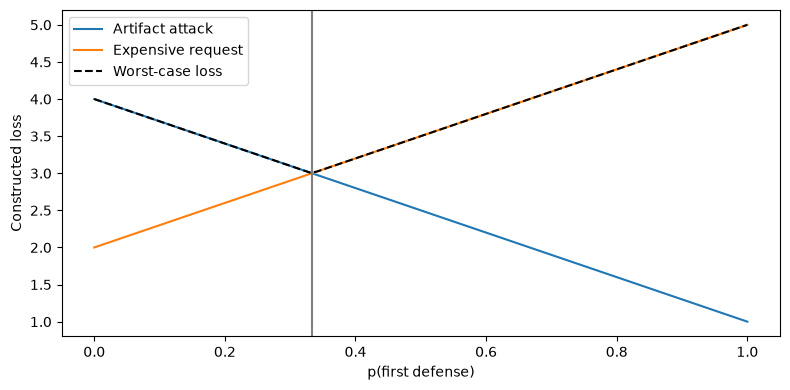

{'p': [0.3333333333333333, 0.6666666666666667], 'q': [0.5, 0.5], 'value': 3.0000000000000004, 'gap': 4.440892098500626e-16}


In [8]:
def game_gap(A,p,q):
    upper=np.max(p@A)
    lower=np.min(A@q)
    return float(upper-lower),float(lower),float(upper)

equilibrium=solve_zero_sum(A)
if equilibrium is None:
    pending("A1")
else:
    p,q,v=equilibrium
    np.testing.assert_allclose(p,[1/3,2/3],atol=1e-8)
    np.testing.assert_allclose(q,[.5,.5],atol=1e-8)
    assert np.isclose(v,3) and game_gap(A,p,q)[0]<1e-8
    for matrix in [A-10,np.array([[2.,2.],[2.,2.]])]:
        pp,qq,vv=solve_zero_sum(matrix)
        assert (pp>=-1e-9).all() and (qq>=-1e-9).all()
        assert np.isclose(pp.sum(),1) and np.isclose(qq.sum(),1)
        assert game_gap(matrix,pp,qq)[0]<1e-8
    grid=np.linspace(0,1,101)
    curves=np.array([np.array([r,1-r])@A for r in grid])
    plt.plot(grid,curves[:,0],label=attacks[0]);plt.plot(grid,curves[:,1],label=attacks[1])
    plt.plot(grid,curves.max(axis=1),"k--",label="Worst-case loss")
    plt.axvline(p[0],color="gray");plt.xlabel("p(first defense)");plt.ylabel("Constructed loss")
    plt.legend();plt.tight_layout();plt.show()
    results["matrix_game"]={"p":p.tolist(),"q":q.tolist(),"value":v,"gap":game_gap(A,p,q)[0]}
    completed.append("A")
    print(results["matrix_game"])

## B. Повторяемая игра и no-regret learning

Используем full-information feedback: после раунда доступны потери ВСЕХ действий, не только сыгранного.
Обновления обоих игроков вычисляются по старым p_t,q_t одновременно.
Для защитника log-weights уменьшаются на \(\eta A q_t\), для атакующего увеличиваются на \(\eta A^\top p_t\).
Анализ no-regret и усреднения в zero-sum играх: [CMU](https://www.andrew.cmu.edu/user/ianagnos/lecture_notes-cmu15888/L4.pdf).

### Задание B1. Одновременное обновление log-weights 

Верните две новые копии log-weights. Знаки различны, потому что один игрок минимизирует,
другой максимизирует. Нельзя использовать уже обновлённое p при расчёте второго игрока.

In [9]:
def mwu_step(logp, logq, A, eta):
    # Старые смешанные стратегии
    p = softmax(logp)
    q = softmax(logq)

    # Защитник минимизирует loss
    loss_p = A @ q

    # Атакующий максимизирует payoff
    payoff_q = A.T @ p

    # Одновременное обновление log-weights
    new_logp = logp - eta * loss_p
    new_logq = logq + eta * payoff_q

    # Возвращаем НОВЫЕ копии
    return new_logp.copy(), new_logq.copy()

,T,eta,average_p,average_q,average_gap,defender_regret,attacker_regret
0,4000,0.004743,"[0.32525560926466823, 0.674744390735333]","[0.5044112915854084, 0.49558870841459146]",0.041878,23.401679,144.111675


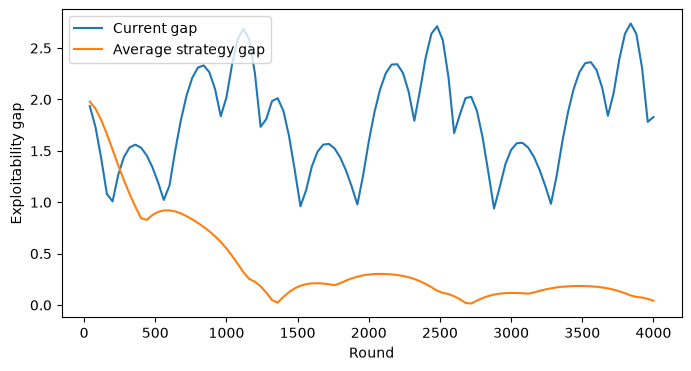

In [10]:
probe=mwu_step(np.zeros(2),np.zeros(2),A,.01)
if probe is None:
    pending("B1")
else:
    testp,testq=mwu_step(np.zeros(2),np.zeros(2),A,.2)
    # Потери строк при uniform: 3 и 3, поэтому p остаётся uniform.
    np.testing.assert_allclose(softmax(testp),[.5,.5])
    assert softmax(testq)[1]>.5  # payoff columns: 2.5 и 3.5
    T=4000; eta=.3/np.sqrt(T)
    lp=np.log([.8,.2]);lq=np.log([.2,.8])
    ps=[];qs=[];losses=[];hist=[]
    for t in range(T):
        pp,qq=softmax(lp),softmax(lq)
        ps.append(pp);qs.append(qq);losses.append(pp@A@qq)
        lp,lq=mwu_step(lp,lq,A,eta)
        if (t+1)%40==0:
            pm,qm=np.mean(ps,axis=0),np.mean(qs,axis=0)
            hist.append({"round":t+1,"current_gap":game_gap(A,pp,qq)[0],
                         "average_gap":game_gap(A,pm,qm)[0]})
    P,Q=np.array(ps),np.array(qs)
    reg_d=np.sum(losses)-np.min((A@Q.T).sum(axis=1))
    reg_a=np.max((P@A).sum(axis=0))-np.sum(losses)
    gap=game_gap(A,P.mean(0),Q.mean(0))[0]
    assert np.isclose((reg_d+reg_a)/T,gap,atol=1e-10)
    results["mwu"]={"T":T,"eta":eta,"average_p":P.mean(0).tolist(),"average_q":Q.mean(0).tolist(),
                    "average_gap":gap,"defender_regret":float(reg_d),"attacker_regret":float(reg_a)}
    display(pd.DataFrame([results["mwu"]]))
    h=pd.DataFrame(hist)
    plt.plot(h["round"],h.current_gap,label="Current gap")
    plt.plot(h["round"],h.average_gap,label="Average strategy gap")
    plt.xlabel("Round");plt.ylabel("Exploitability gap");plt.legend();plt.show()
    completed.append("B")

## C. Почему минимакс не гарантирует сходимость градиентов

Изучаем $ \min_x\max_y xy $ на R², равновесие (0,0).

Одновременный GDA: $\($x'=x-\eta y,\ y'=y+\eta x$.

Длина вектора увеличивается в $\sqrt{1+\eta^2}$ раза.

Extragradient сначала делает пробный шаг, затем вычисляет обновление из исходной точки по градиенту в пробной. Это аналитический учебный пример, не обучение GAN.

### Задание C1. Extra-gradient step 

Сначала вычислите x_mid=x-eta*y и y_mid=y+eta*x.
Затем обновите исходные x,y градиентом в середине; не делайте второй шаг из mid.

In [11]:
def extra_step(x, y, eta):
    # 1. Пробный шаг из исходной точки
    x_mid = x - eta * y
    y_mid = y + eta * x

    # 2. Коррекция: градиент берём в mid,
    #    но шаг делаем из ИСХОДНОЙ точки x, y
    x_new = x - eta * y_mid
    y_new = y + eta * x_mid

    return x_new, y_new

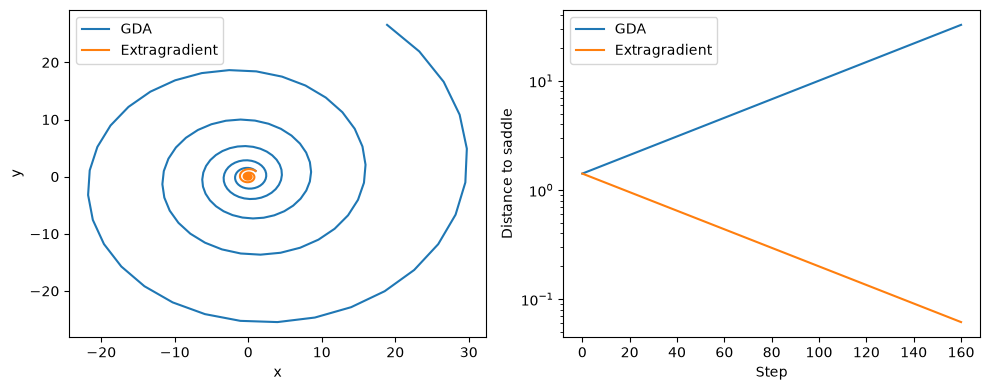

In [12]:
if extra_step(1.,1.,.2) is None:
    pending("C1")
else:
    eta=.2;steps=160
    gd=np.array([1.,1.]);eg=gd.copy()
    gd_path=[gd.copy()];eg_path=[eg.copy()]
    for _ in range(steps):
        x,y=gd
        gd=np.array([x-eta*y,y+eta*x])
        eg=np.array(extra_step(*eg,eta))
        gd_path.append(gd.copy());eg_path.append(eg.copy())
    gd_path,eg_path=np.array(gd_path),np.array(eg_path)
    ng=np.linalg.norm(gd_path,axis=1);ne=np.linalg.norm(eg_path,axis=1)
    np.testing.assert_allclose(ng[1]/ng[0],np.sqrt(1+eta**2))
    np.testing.assert_allclose(ne[1]/ne[0],np.sqrt((1-eta**2)**2+eta**2))
    assert ng[-1]>ng[0] and ne[-1]<ne[0]
    fig,ax=plt.subplots(1,2,figsize=(10,4))
    ax[0].plot(gd_path[:,0],gd_path[:,1],label="GDA")
    ax[0].plot(eg_path[:,0],eg_path[:,1],label="Extragradient")
    ax[0].set(xlabel="x",ylabel="y");ax[0].legend()
    ax[1].semilogy(ng,label="GDA");ax[1].semilogy(ne,label="Extragradient")
    ax[1].set(xlabel="Step",ylabel="Distance to saddle");ax[1].legend()
    plt.tight_layout();plt.show()
    results["bilinear"]={"eta":eta,"steps":steps,"GDA_final_norm":float(ng[-1]),
                         "extragradient_final_norm":float(ne[-1])}
    completed.append("C")

## D. Stackelberg: сначала обязательство, затем лучший ответ

Защитник публикует вероятность p проверки артефактов, но атакующий не видит исход случайной проверки
до выбора атаки. Это наблюдение ПОЛИТИКИ, не реализации действия.
Все utility ниже условны и сконструированы.

Выгода атакующего: U_artifact=6-8p, U_latency=2+2p, U_abstain=0.
Потери защитника: L_artifact=8-5p, L_latency=2+2p, L_abstain=p.
В отличие от zero-sum игры, потери защитника не равны выгоде атакующего.
При равных лучших ответах сравниваем благоприятное и неблагоприятное для защитника разрешение ничьей
([Stackelberg security games](https://bc.itl.waw.pl/Content/1933/ISSN_1509-4553_3_2016_70.pdf)).

### Задание D1. Ответ последователя и tie-breaking

Выберите все действия с максимальной U_attacker в пределах atol.
Из них при favorable выберите минимум L_defender, при pessimistic максимум.
Верните индекс выбранного действия; минимизировать L по всем действиям атакующего нельзя.

In [13]:
def follower_response(attacker_util, defender_loss,
                      tie="pessimistic", atol=1e-10):

    # 1. Проверяем допустимость tie-breaking
    if tie not in ("favorable", "pessimistic"):
        raise ValueError("tie must be 'favorable' or 'pessimistic'")

    # 2. Находим максимальную utility атакующего
    max_u = np.max(attacker_util)

    # 3. Формируем множество лучших ответов атакующего
    best = np.flatnonzero(
        np.isclose(attacker_util, max_u, atol=atol, rtol=0.0)
    )

    # 4. Разрешаем ничью по loss защитника
    if tie == "favorable":
        j = best[np.argmin(defender_loss[best])]
    else:
        j = best[np.argmax(defender_loss[best])]

    return int(j)

,p,tie,action,defender_loss
0,0.400,favorable,1,2.800
1,0.401,pessimistic,1,2.802


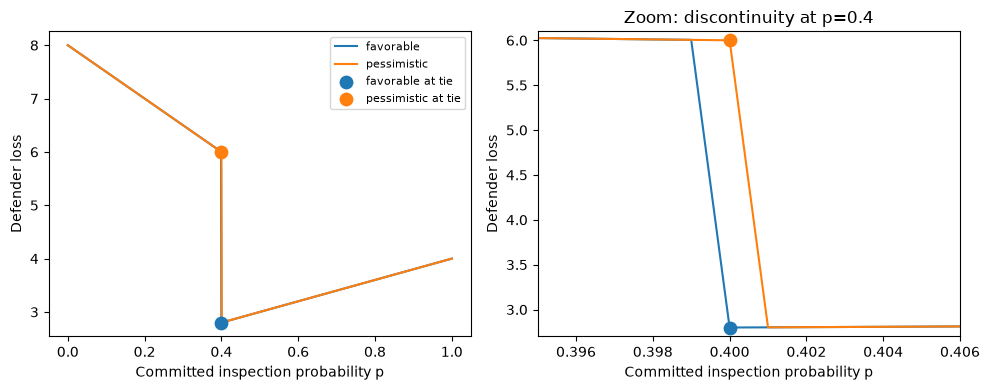

Решение по сетке НЕ объявляется точным непрерывным pessimistic equilibrium.
При p=0.4 utility равны; unfavorable loss=6. Для p>0.4 loss=2+2p.
Pessimistic infimum 2.8 приближается справа, но в непрерывной задаче не достигается.


In [14]:
if follower_response(np.array([1.,1.]),np.array([5.,2.])) is None:
    pending("D1")
else:
    assert follower_response(np.array([1.,1.]),np.array([5.,2.]),"favorable")==1
    assert follower_response(np.array([1.,1.]),np.array([5.,2.]),"pessimistic")==0
    rows=[]
    grid=np.linspace(0,1,1001)
    for pp in grid:
        au=np.array([6-8*pp,2+2*pp,0.])
        dl=np.array([8-5*pp,2+2*pp,pp])
        for tie in ["favorable","pessimistic"]:
            j=follower_response(au,dl,tie)
            rows.append({"p":pp,"tie":tie,"action":j,"defender_loss":dl[j]})
    sdf=pd.DataFrame(rows)
    selected=sdf.loc[sdf.groupby("tie").defender_loss.idxmin()].reset_index(drop=True)
    display(selected)
    fig,axes=plt.subplots(1,2,figsize=(10,4))
    for ax in axes:
        for tie in ["favorable","pessimistic"]:
            sub=sdf[sdf.tie==tie]
            ax.plot(sub.p,sub.defender_loss,label=tie)
        ax.scatter([.4],[2.8],s=80,color="tab:blue",zorder=5,label="favorable at tie")
        ax.scatter([.4],[6.],s=80,color="tab:orange",zorder=5,label="pessimistic at tie")
        ax.set(xlabel="Committed inspection probability p",ylabel="Defender loss")
    axes[1].set_xlim(.395,.406);axes[1].set_ylim(2.7,6.1)
    axes[0].legend(fontsize=8);axes[1].set_title("Zoom: discontinuity at p=0.4")
    plt.tight_layout();plt.show()
    print("Решение по сетке НЕ объявляется точным непрерывным pessimistic equilibrium.")
    print("При p=0.4 utility равны; unfavorable loss=6. Для p>0.4 loss=2+2p.")
    print("Pessimistic infimum 2.8 приближается справа, но в непрерывной задаче не достигается.")
    results["stackelberg_grid"]=selected.to_dict("records")
    completed.append("D")

## E. От игры к настоящей нейросети: матрица измеренных ошибок

Обучаем три маленькие MLP на локальных цифрах: ERM, noise augmentation и adversarial training.
Столбцы матрицы: random L∞ perturbation, FGSM и PGD. Все радиусы 0.10 в [0,1].
Каждая ячейка использует white-box доступ к соответствующей строке-модели.

Это ограниченная игра между БИБЛИОТЕКАМИ политик. Атакующий заранее выбирает алгоритм,
затем этот алгоритм может работать с выбранной моделью. Это не сертификат против всех адаптивных атак
и не утверждение о безопасности скрытого случайного роутинга.

Вероятности защитника выбираются только по development-матрице; test используется после фиксации p.
Доминирование одного столбца и чистое оптимальное решение являются допустимым результатом.

DEVELOPMENT loss matrix


,random,FGSM,PGD
ERM,0.025000,0.491667,0.533333
Noise,0.025000,0.416667,0.483333
AT,0.066667,0.266667,0.283333


TEST loss matrix; p не переоптимизируется


,random,FGSM,PGD
ERM,0.041667,0.483333,0.516667
Noise,0.033333,0.450000,0.491667
AT,0.041667,0.216667,0.241667


p_fixed = [0. 0. 1.] ; test loss by column = [0.04166669 0.21666664 0.24166667]


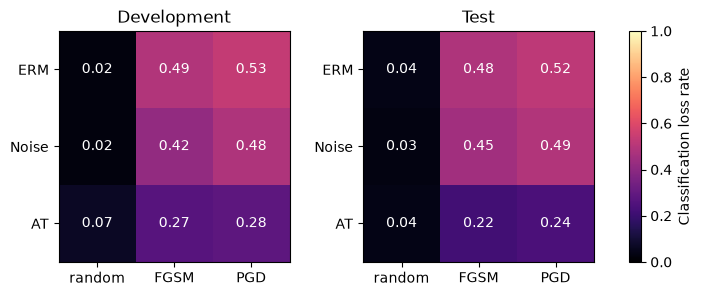

In [15]:
digits=load_digits()
X=(digits.data/16).astype(np.float32);Y=digits.target
rest,test_ids=train_test_split(np.arange(len(Y)),test_size=500,random_state=10,stratify=Y)
train_ids,dev_ids=train_test_split(rest,train_size=900,random_state=11,stratify=Y[rest])
dev_audit,_=train_test_split(dev_ids,train_size=120,random_state=12,stratify=Y[dev_ids])
test_audit,_=train_test_split(test_ids,train_size=120,random_state=13,stratify=Y[test_ids])
assert not set(dev_ids)&set(test_ids) and not set(train_ids)&set(test_ids)
xt=torch.tensor(X[train_ids]);yt=torch.tensor(Y[train_ids],dtype=torch.long)
def model_new(seed):
    torch.manual_seed(seed)
    return nn.Sequential(nn.Linear(64,32),nn.ReLU(),nn.Linear(32,10))
def project(z,x,eps):
    return torch.maximum((x-eps).clamp(0,1),torch.minimum(z,(x+eps).clamp(0,1)))
def attack(model,x,y,kind,seed=42):
    eps=.1;gen=torch.Generator().manual_seed(seed)
    if kind=="random":
        return project(x+eps*(2*torch.rand(x.shape,generator=gen)-1),x,eps)
    z=x.clone() if kind=="FGSM" else project(x+eps*(2*torch.rand(x.shape,generator=gen)-1),x,eps)
    steps=1 if kind=="FGSM" else 15
    step=.1 if kind=="FGSM" else .02
    with torch.no_grad():
        best=x.clone();bestloss=F.cross_entropy(model(best),y,reduction="none")
        bestbad=model(best).argmax(1)!=y
    for _ in range(steps):
        z.requires_grad_(True)
        grad=torch.autograd.grad(F.cross_entropy(model(z),y),z)[0]
        z=project(z.detach()+step*grad.sign(),x,eps).detach()
        with torch.no_grad():
            logits=model(z);bad=logits.argmax(1)!=y
            loss=F.cross_entropy(logits,y,reduction="none")
            use=(bad&~bestbad)|((bad==bestbad)&(loss>bestloss))
            best[use]=z[use];bestloss[use]=loss[use];bestbad[use]=bad[use]
    return best

networks={}
for mode in ["ERM","Noise","AT"]:
    m=model_new(70)
    opt=torch.optim.Adam(m.parameters(),lr=.01,weight_decay=1e-4)
    gen=torch.Generator().manual_seed(71)
    for epoch in range(90):
        if mode=="Noise": train_x=(xt+.1*torch.randn(xt.shape,generator=gen)).clamp(0,1)
        elif mode=="AT": train_x=attack(m,xt,yt,"FGSM",seed=epoch)
        else: train_x=xt
        opt.zero_grad()
        loss=F.cross_entropy(m(train_x),yt)
        loss.backward();opt.step()
    networks[mode]=m.eval()

def payoff_matrix(indices):
    x=torch.tensor(X[indices]);y=torch.tensor(Y[indices],dtype=torch.long)
    matrix=np.zeros((3,3))
    for i,(name,m) in enumerate(networks.items()):
        with torch.no_grad(): clean_ok=m(x).argmax(1)==y
        for j,kind in enumerate(["random","FGSM","PGD"]):
            adv=attack(m,x,y,kind,seed=80)
            assert (adv-x).abs().max()<=.100001
            with torch.no_grad(): ok=m(adv).argmax(1)==y
            # Включаем исходный вход, поэтому чистые ошибки не "исправляются" атакой.
            matrix[i,j]=1-(ok&clean_ok).float().mean().item()
    return matrix
dev_matrix=payoff_matrix(dev_audit)
print("DEVELOPMENT loss matrix");display(pd.DataFrame(dev_matrix,index=list(networks),columns=["random","FGSM","PGD"]))
if solve_zero_sum(dev_matrix) is None:
    pending("E: нужен A1")
else:
    pdev,qdev,vdev=solve_zero_sum(dev_matrix)  # фиксируем до test
    test_matrix=payoff_matrix(test_audit)
    test_expected=pdev@test_matrix
    results["empirical_game"]={"development":dev_matrix.tolist(),"p_fixed":pdev.tolist(),
                               "q_development":qdev.tolist(),"development_value":vdev,
                               "test":test_matrix.tolist(),"test_expected_loss_by_attack":test_expected.tolist(),
                               "test_worst_library_loss":float(test_expected.max())}
    print("TEST loss matrix; p не переоптимизируется")
    display(pd.DataFrame(test_matrix,index=list(networks),columns=["random","FGSM","PGD"]))
    print("p_fixed =",pdev,"; test loss by column =",test_expected)
    fig,ax=plt.subplots(1,2,figsize=(9,3))
    for a,matrix,title in zip(ax,[dev_matrix,test_matrix],["Development","Test"]):
        im=a.imshow(matrix,vmin=0,vmax=1,cmap="magma")
        a.set_xticks(range(3),["random","FGSM","PGD"])
        a.set_yticks(range(3),list(networks));a.set_title(title)
        for i in range(3):
            for j in range(3): a.text(j,i,f"{matrix[i,j]:.2f}",ha="center",va="center",color="white" if matrix[i,j]<.6 else "black")
    fig.colorbar(im,ax=ax.ravel().tolist(),label="Classification loss rate")
    plt.show();completed.append("E")

## F. Supply chain: подпись, digest, политика и поведенческая проверка

Используем маленький JSON с числовыми весами, НЕ pickle и НЕ исполняемый checkpoint.
Ключ Ed25519 создаётся локально только для учебной подписи; не сохраняется и не отправляется.
Verifier получает только public key через доверенную конфигурацию, не из приложенного артефакта.
Подписывается canonical JSON-манифест с SHA-256 артефакта, builder, source, release и dependencies.

Это мини-протокол, НЕ реализация SLSA/in-toto и не присвоение уровня SLSA.
Смысл проверок соответствует [SLSA verification](https://slsa.dev/spec/v1.2/verifying-artifacts).
Сведения о компонентах и данных полезны, но не заменяют их проверку
([NIST SP 800-218A](https://nvlpubs.nist.gov/nistpubs/SpecialPublications/NIST.SP.800-218A.pdf)).

In [16]:
def canonical(obj):
    return json.dumps(obj,sort_keys=True,separators=(",",":"),allow_nan=False).encode("utf-8")
def digest(blob): return hashlib.sha256(blob).hexdigest()
signer=Ed25519PrivateKey.generate()
trusted_public=signer.public_key()
attacker_signer=Ed25519PrivateKey.generate()
artifact=canonical({"weights":[[2.,-2.],[-2.,2.]],"bias":[0.,0.]})
expected_policy={"builder":"local-course-builder","source":"course/approved-model",
                 "commit":"revision-002","release":2,"dependencies":{"lab-runtime":"1.0"}}
manifest={**expected_policy,"sha256":digest(artifact),"format":"numeric-json-v1"}
signature=signer.sign(canonical(manifest))

### Задание F1. Admission gate артефакта (15 баллов)

Сначала ограничьте размер bytes 16 KiB, затем проверьте подпись canonical(manifest) доверенным public key.
Проверьте digest, точное совпадение builder/source/commit/release/dependencies и format.
Отклоните неизвестные поля. Верните (True,"verified") или (False,reason).
Частный ключ signer НЕ должен использоваться внутри verifier.

In [17]:
def verify_artifact(blob, meta, sig, public_key, policy):
    # 1. Ограничение размера
    if len(blob) > 16 * 1024:
        return False, "artifact_too_large"

    # 2. Проверка схемы manifest:
    #    неизвестные и отсутствующие поля запрещены
    allowed_fields = {
        "builder",
        "source",
        "commit",
        "release",
        "dependencies",
        "sha256",
        "format",
    }

    if set(meta) != allowed_fields:
        return False, "unexpected_manifest_fields"

    # 3. Проверка подписи доверенным public key
    try:
        public_key.verify(sig, canonical(meta))
    except InvalidSignature:
        return False, "invalid_signature"

    # 4. Проверка digest самого артефакта
    if digest(blob) != meta["sha256"]:
        return False, "digest_mismatch"

    # 5. Проверка формата
    if meta["format"] != "numeric-json-v1":
        return False, "invalid_format"

    # 6. Проверка ожидаемой политики
    for key in ("builder", "source", "commit", "release", "dependencies"):
        if meta[key] != policy[key]:
            return False, f"policy_mismatch:{key}"

    return True, "verified"

In [ ]:
# Проверяем веса/содержимое модели
def safe_numeric_parse(blob):
    obj=json.loads(blob)
    if set(obj)!={"weights","bias"}: raise ValueError("unexpected model fields")
    W=np.asarray(obj["weights"],dtype=float);b=np.asarray(obj["bias"],dtype=float)
    if W.shape!=(2,2) or b.shape!=(2,): raise ValueError("shape")
    if not np.isfinite(W).all() or not np.isfinite(b).all(): raise ValueError("non-finite")
    if np.abs(W).max()>10 or np.abs(b).max()>10: raise ValueError("numeric range")
    return W,b
# Тестируем модель
def smoke_score(W,b):
    x=np.array([[1.,0.],[.8,.2],[0.,1.],[.2,.8]])
    y=np.array([0,0,1,1])
    return float(((x@W.T+b).argmax(1)==y).mean())
# Проверяем все вместе
def release_gate(blob,meta,sig):
    verdict=verify_artifact(blob,meta,sig,trusted_public,expected_policy)
    if verdict is None: return None
    ok,reason=verdict
    if not ok: return False,reason,None
    try: W,b=safe_numeric_parse(blob)
    except (ValueError,TypeError,KeyError): return False,"numeric_schema",None
    score=smoke_score(W,b)
    return score>=1.0, "release_candidate" if score>=1.0 else "behavior_test",score

if verify_artifact(artifact,manifest,signature,trusted_public,expected_policy) is None:
    pending("F1")
else:
    changed=canonical({"weights":[[-2.,2.],[2.,-2.]],"bias":[0.,0.]})
    updated={**manifest,"sha256":digest(changed)}
    wrong_source={**manifest,"source":"course/unapproved-fork"}
    stale={**manifest,"release":1}
    cases=[
        ("valid",artifact,manifest,signature,True),
        ("changed weights",changed,manifest,signature,False),
        ("changed digest without signature",changed,updated,signature,False),
        ("untrusted self-signer",artifact,manifest,attacker_signer.sign(canonical(manifest)),False),
        ("signed wrong source",artifact,wrong_source,signer.sign(canonical(wrong_source)),False),
        ("signed stale release",artifact,stale,signer.sign(canonical(stale)),False),
        ("trusted signer, bad behavior",changed,updated,signer.sign(canonical(updated)),False)]
    gate_rows=[]
    for name,blob,meta,sig,expected in cases:
        admitted,reason,score=release_gate(blob,meta,sig)
        assert admitted==expected,(name,reason)
        gate_rows.append({"scenario":name,"admitted":bool(admitted),"reason":reason,"smoke_accuracy":score})
    results["release_gate"]=gate_rows;display(pd.DataFrame(gate_rows));completed.append("F")
    print("PASS != отсутствие backdoor. Четыре smoke-примера проверяют только узкую известную спецификацию.")
    print("Все подписи созданы внутри локального стенда; реальные production-ключи не используются.")

,scenario,admitted,reason,smoke_accuracy
0,valid,True,release_candidate,1.0
1,changed weights,False,digest_mismatch,NaN
2,changed digest without signature,False,invalid_signature,NaN
3,untrusted self-signer,False,invalid_signature,NaN
4,signed wrong source,False,policy_mismatch:source,NaN
5,signed stale release,False,policy_mismatch:release,NaN
6,"trusted signer, bad behavior",False,behavior_test,0.0


PASS != отсутствие backdoor. Четыре smoke-примера проверяют только узкую известную спецификацию.
Все подписи созданы внутри локального стенда; реальные production-ключи не используются.


## G. Latency: локальная ограниченная нагрузка и отдельная симуляция очереди

Sponge examples направлены на затраты и задержки, а не обязательно на ошибочную метку
([Shumailov et al.](https://arxiv.org/abs/2006.03463)).
Ниже измеряется только локальная CPU-latency attention для фиксированного набора длин.
Это workload stress demonstration, НЕ оптимизированная sponge-атака на промышленную модель.
Энергия устройства не измеряется. Dense attention не становится дешевле просто из-за нулевых значений.

,tokens,median_ms,p95_ms,timing_windows,MAC_QK_AV,attention_score_bytes_float32
0,32,0.03848,0.05632,31,65536,4096
1,64,0.05306,0.07550,31,262144,16384
2,128,0.09926,0.14052,31,1048576,65536
3,256,0.27310,0.37637,31,4194304,262144


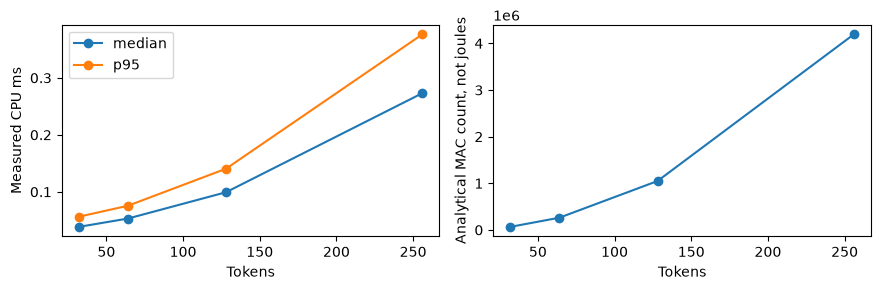

p95 относится к среднему из 5 операций в окне, не к p95 сетевого сервиса.


In [19]:
LENGTHS=[32,64,128,256]
D=32
hard_limit=256
def attention(q,k,v):
    return torch.softmax(q@k.T/np.sqrt(D),dim=-1)@v
gen=torch.Generator().manual_seed(99)
inputs={L:tuple(torch.randn((L,D),generator=gen) for _ in range(3)) for L in LENGTHS}
assert max(LENGTHS)<=hard_limit
measurements={L:[] for L in LENGTHS}
rounds=31
with torch.inference_mode():
    for L in LENGTHS:
        for _ in range(6): attention(*inputs[L])
    rng=np.random.default_rng(101)
    for _ in range(rounds):
        for L in rng.permutation(LENGTHS):
            t0=time.perf_counter_ns()
            for _ in range(5): attention(*inputs[L])
            ns=(time.perf_counter_ns()-t0)/5
            measurements[L].append(ns/1e6)
latency_rows=[]
for L in LENGTHS:
    a=np.array(measurements[L])
    latency_rows.append({"tokens":L,"median_ms":float(np.median(a)),"p95_ms":float(np.quantile(a,.95)),
                         "timing_windows":rounds,"MAC_QK_AV":2*L*L*D,
                         "attention_score_bytes_float32":L*L*4})
results["local_latency"]=latency_rows
display(pd.DataFrame(latency_rows))
fig,ax=plt.subplots(1,2,figsize=(9,3))
df=pd.DataFrame(latency_rows)
ax[0].plot(df.tokens,df.median_ms,"o-",label="median")
ax[0].plot(df.tokens,df.p95_ms,"o-",label="p95")
ax[0].set(xlabel="Tokens",ylabel="Measured CPU ms");ax[0].legend()
ax[1].plot(df.tokens,df.MAC_QK_AV,"o-")
ax[1].set(xlabel="Tokens",ylabel="Analytical MAC count, not joules")
plt.tight_layout();plt.show()
print("p95 относится к среднему из 5 операций в окне, не к p95 сетевого сервиса.")

### Задание G1. Проверка входного бюджета до expensive compute (10 баллов)

Верните (admit, reason, token_count).
Проверьте размер UTF-8 bytes ДО split, затем число whitespace-токенов.
Учебный token counter не является tokenizer LLM. Не выполняйте attention для отклонённых запросов.

In [20]:
def admit_request(text, max_bytes=4096, max_tokens=128):
    # 1. Проверяем тип
    if not isinstance(text, str):
        return False, "type", 0

    # 2. Считаем размер UTF-8 ДО split
    size = len(text.encode("utf-8"))
    if size > max_bytes:
        return False, "bytes", 0

    # 3. Пустой запрос
    if not text.strip():
        return False, "empty", 0

    # 4. Учебный token counter:
    #    один whitespace-separated элемент = один токен
    token_count = len(text.split())

    # 5. Ограничение количества токенов
    if token_count > max_tokens:
        return False, "tokens", token_count

    return True, "admitted", token_count

,token_cap,benign_n,benign_admission_rate,benign_SLO_success_all,benign_p95_ms_served,attacker_admission_rate,offered_utilization_proxy
0,256,509,1.000000,0.019646,1644.0,1.0,1.550000
1,128,509,0.911591,0.911591,2.0,0.0,0.309333


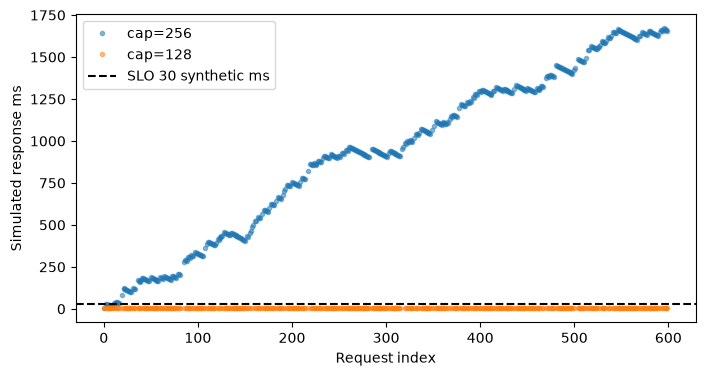

Отклонённые benign входят в провалы SLO. p95 served отдельно исключает rejected.
Лимит может отклонить законный длинный запрос; utility != 100%.


In [21]:
def fcfs(arrivals,services,admitted):
    finished=0.;lat=np.full(len(arrivals),np.nan)
    for i,(arrival,service,ok) in enumerate(zip(arrivals,services,admitted)):
        if ok:
            finished=max(arrival,finished)+service
            lat[i]=finished-arrival
    return lat

if admit_request("test") is None:
    pending("G1")
else:
    assert admit_request("x "*129)[0] is False
    assert admit_request("x"*5000)[1]=="bytes"
    assert admit_request("")[0] is False
    assert admit_request("ok")[0] is True
    # SIMULATION: service times below are constructed, NOT measured latency_rows.
    rng=np.random.default_rng(120)
    n=600;arrivals=np.arange(n)*5.0
    u=rng.random(n)
    malicious=u<.15
    benign_long=(u>=.15)&(u<.20)
    lengths=np.where(malicious,256,np.where(benign_long,192,64))
    services=2.0*(lengths/64)**2  # synthetic ms
    benign=~malicious
    queue_rows=[];paths={}
    for cap in [256,128]:
        admitted=np.array([admit_request("x "*int(L),max_tokens=cap)[0] for L in lengths])
        lat=fcfs(arrivals,services,admitted)
        served_benign=benign&admitted
        deadline=30.0
        good=benign&admitted&(lat<=deadline)
        row={"token_cap":cap,"benign_n":int(benign.sum()),
             "benign_admission_rate":float(admitted[benign].mean()),
             "benign_SLO_success_all":float(good.sum()/benign.sum()),
             "benign_p95_ms_served":float(np.quantile(lat[served_benign],.95)),
             "attacker_admission_rate":float(admitted[malicious].mean()),
             "offered_utilization_proxy":float(np.mean(services[admitted])*np.mean(admitted)/5)}
        queue_rows.append(row);paths[cap]=lat
    results["queue_simulation"]=queue_rows
    display(pd.DataFrame(queue_rows))
    for cap,lat in paths.items(): plt.plot(np.flatnonzero(benign),lat[benign],".",label=f"cap={cap}",alpha=.5)
    plt.axhline(30,color="black",linestyle="--",label="SLO 30 synthetic ms")
    plt.xlabel("Request index");plt.ylabel("Simulated response ms");plt.legend();plt.show()
    print("Отклонённые benign входят в провалы SLO. p95 served отдельно исключает rejected.")
    print("Лимит может отклонить законный длинный запрос; utility != 100%.")
    completed.append("G")

## H. Энергия и итоговый отчёт

Энергия есть интеграл мощности по времени; latency, MAC и доля ненулевых активаций сами по себе не являются джоулями.
Следующий массив мощности полностью СИНТЕТИЧЕСКИЙ, только для проверки единиц и интегрирования.
Реальных измерений энергопотребления в блокноте нет.

### Задание H1. Интеграл мощности (5 баллов)

Реализуйте метод трапеций для времени в секундах и мощности в ваттах.
Верните полную энергию и baseline-subtracted энергию, не обрезая вторую снизу нулём.
Проверьте одинаковую длину массивов и строго возрастающее время.

In [22]:
def integrate_energy(t, power, idle_watts):
    t = np.asarray(t, dtype=float)
    power = np.asarray(power, dtype=float)

    if len(t) != len(power):
        raise ValueError("t and power must have the same length")

    if len(t) < 2:
        raise ValueError("at least two time points are required")

    if not np.all(np.diff(t) > 0):
        raise ValueError("time must be strictly increasing")

    total = np.trapezoid(power, t)

    duration = t[-1] - t[0]
    baseline = idle_watts * duration

    incremental = total - baseline

    return float(total), float(incremental)

In [23]:
answer=integrate_energy([0,.1,.2,.3],[10,14,12,10],10)
if answer is None:
    pending("H1")
else:
    total,incremental=answer
    np.testing.assert_allclose([total,incremental],[3.6,.6])
    results["synthetic_energy_example"]={"total_J":total,"above_idle_J":incremental,
                                        "measurement_type":"synthetic teaching fixture, NOT device measurement"}
    print(results["synthetic_energy_example"]);completed.append("H")

{'total_J': 3.5999999999999996, 'above_idle_J': 0.5999999999999996, 'measurement_type': 'synthetic teaching fixture, NOT device measurement'}


## Итоговое задание I. Отчёт и объединение результатов (10 баллов)

Сдайте выполненный `.ipynb`, результаты, версии среды и короткое заключение.
В отчёте должны быть:

- **Игра**: игроки, действия, наблюдаемость, знак utility, происхождение матрицы, p/q/value/gap.
- **Динамика**: текущая и средняя стратегии, объяснение циклов и ограничения bilinear-модели.
- **ML**: выбор стратегии только по development и оценка по held-out test, без повторной оптимизации.
- **Supply chain**: доверенный ключ, подпись, digest, ожидания, поведенческий тест; что проверки НЕ доказывают.
- **Стоимость**: измеренная локальная latency отдельно от симуляции очереди и синтетического интеграла энергии.
- **Решение**: предложите бюджетную политику и разберите её цену для легитимных пользователей.

Необязательное расширение: 3 seed эмпирической матрицы, доверительные интервалы latency с корректной единицей
повторения, или байесовская модель двух типов атакующего с явно заданным prior.
Никаких нагрузочных запросов к внешним сервисам или загрузки чужих checkpoint.

Баллы: A1 15 + B1 10 + C1 10 + D1 10 + F1 15 + G1 10 + H1 5 + I 10
+ 15 за интерпретацию development/test-матрицы в блоке E = 100.
В блоке E код дан, но объяснение модели угроз и границ выводов обязательно.

In [24]:
missing=[x for x in "ABCDEFGH" if x not in completed]
print("Незавершённые разделы:",missing)
print(f"Время исполнения: {time.perf_counter()-START:.1f} с")
# При необходимости:
# from pathlib import Path
# Path("lecture12_results.json").write_text(json.dumps(results,ensure_ascii=False,indent=2),encoding="utf-8")

Незавершённые разделы: []
Время исполнения: 22305.0 с


## Итоговый вывод по каждому разделу

A. В матричной игре мы нашли смешанные стратегии защиты и атаки. Для нашей матрицы оптимальная стратегия защиты — выбирать второй вариант с вероятностью 2/3, а значение игры получилось равным 3.

B. Метод мультипликативных весов показал, что даже если стратегии со временем колеблются, их средние значения могут приближаться к равновесию. То есть не обязательно каждый отдельный шаг будет хорошим — важен результат на длинной серии ходов.

C. Для простой игры с функцией xy обычный градиентный метод оказался нестабильным: точки начинают раскручиваться вокруг равновесия и уходить от него. Метод с дополнительным шагом исправляет это и позволяет постепенно приближаться к точке равновесия.

D. В игре с последовательными решениями защитник сначала выбирает свою стратегию, а атакующий уже реагирует на неё. Здесь хорошо видно, что даже небольшая разница в правилах выбора при равных вариантах может сильно изменить итог, поэтому поведение атакующего тоже нужно учитывать.

E. В эксперименте с нейросетями обычное обучение показало ошибку около 53% при худшей атаке, а обучение с учётом атак снизило её примерно до 28% на проверочных данных. На тесте лучший результат тоже был у модели с защитой от атак: максимальная ошибка составила около 24%.

F. Проверка подписи и контрольной суммы позволяют убедиться, что модель действительно пришла от доверенного источника и файл не был изменён. При этом одной подписи недостаточно: дополнительно нужны проверка правил и небольшой тест поведения модели.

G. Ограничение длины запросов заметно помогает защищать систему от слишком тяжёлых запросов. При ограничении 128 токенов все вредные длинные запросы были отклонены, загрузка снизилась примерно до 31%, а задержка для обслуженных обычных запросов составила около 2 мс, хотя при этом около 9% обычных запросов тоже пришлось отклонить.

H. Энергия считается не по количеству операций или времени работы отдельно, а по мощности во времени. В нашем синтетическом примере общая энергия составила 3.6 Дж, из которых 0.6 Дж пришлись именно на потребление сверх обычного фонового уровня.
